In [ ]:
!pip -q install gymnasium torch numpy matplotlib


In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:
class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )
        self.actor = nn.Linear(128, act_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        x = self.net(x)
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value

In [ ]:
def rollout(env, policy, max_steps=200):
    obs, _ = env.reset()
    traj = []
    total_reward = 0

    for _ in range(max_steps):
        obs_t = torch.tensor(obs, dtype=torch.float32)
        logits, _ = policy(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample().item()

        next_obs, reward, done, trunc, _ = env.step(action)

        traj.append((obs, action, reward))
        total_reward += reward

        obs = next_obs
        if done or trunc:
            break

    return traj, total_reward

In [ ]:
def train_reinforce(env_name="CartPole-v1", steps=3000, lr=3e-4):
    env = gym.make(env_name)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = Policy(obs_dim, act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    gamma = 0.99

    pbar = tqdm(range(steps), desc="Training REINFORCE")

    for _ in pbar:
        traj, _ = rollout(env, policy)

        returns = []
        G = 0
        for _, _, r in reversed(traj):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for (obs, action, _), R in zip(traj, returns):
            obs_t = torch.tensor(obs, dtype=torch.float32)
            logits, value = policy(obs_t)
            dist = Categorical(logits=logits)

            log_prob = dist.log_prob(torch.tensor(action))
            advantage = R - value.item()

            loss += -log_prob * advantage + (R - value.squeeze())**2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # optional live loss display
        pbar.set_postfix(loss=float(loss.detach().cpu()))

    return policy, env


In [ ]:
pi1, env = train_reinforce(steps=4000)

In [ ]:
#Load policy from checkpoint
pi1 = Policy(4, 2)
pi1.load_state_dict(torch.load("/content/drive/MyDrive/RL_project/pi1_cartpole.pth"))

<All keys matched successfully>

In [ ]:
def evaluate_policy(policy, env_name="CartPole-v1", episodes=50, render=False):
    env = gym.make(env_name, render_mode="human" if render else None)

    rewards = []

    # progress bar over episodes
    #pbar = tqdm(range(episodes), desc="Evaluating Policy")

    for _ in range(episodes):
        obs, _ = env.reset()

        done = False
        total_reward = 0

        while not done:
            device = next(policy.parameters()).device
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device)
            #obs_t = torch.tensor(obs, dtype=torch.float32)
            logits, _ = policy(obs_t)

            action = torch.argmax(logits).item()  # deterministic eval

            obs, reward, done, trunc, _ = env.step(action)
            total_reward += reward

            if trunc:
                break

        rewards.append(total_reward)

        # live update in progress bar
        #pbar.set_postfix(avg_reward=np.mean(rewards))

    env.close()

    return np.mean(rewards), np.std(rewards), rewards


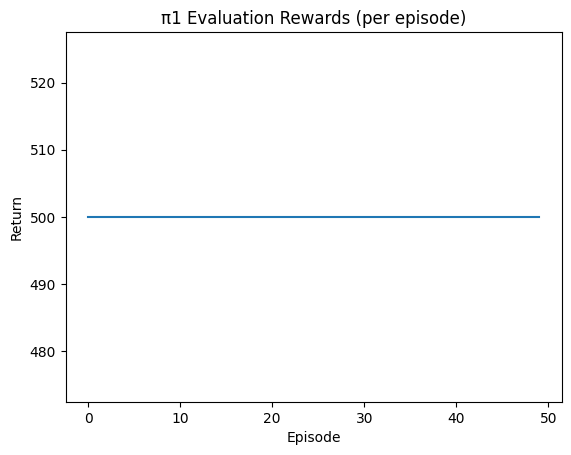

In [ ]:
mean_reward, std_reward, episode_rewards = evaluate_policy(pi1)
import matplotlib.pyplot as plt

plt.plot(episode_rewards)
plt.title("π1 Evaluation Rewards (per episode)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio

def record_policy(policy, env_name="CartPole-v1", filename="cartpole.mp4"):
    env = gym.make(env_name, render_mode="rgb_array")

    frames = []

    obs, _ = env.reset()
    done = False

    while not done:
        frame = env.render()
        frames.append(frame)

        obs_t = torch.tensor(obs, dtype=torch.float32)
        logits, _ = policy(obs_t)

        action = torch.argmax(logits).item()

        obs, reward, done, trunc, _ = env.step(action)

        if trunc:
            break

    env.close()

    imageio.mimsave(filename, frames, fps=30)

    return filename


In [ ]:
video_file = record_policy(pi1)
video_file


'cartpole.mp4'

In [ ]:
from IPython.display import Video

Video(video_file)


In [ ]:
import torch
import torch.nn as nn

class LinearPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()

        # Linear actor: s -> logits
        self.actor = nn.Linear(obs_dim, act_dim)

        # Linear critic: s -> V(s)
        self.critic = nn.Linear(obs_dim, 1)

    def forward(self, x):
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value


In [ ]:
def train_reinforce_linear(env_name="CartPole-v1", steps=3000, lr=3e-4):
    env = gym.make(env_name)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = LinearPolicy(obs_dim, act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    gamma = 0.99

    for _ in tqdm(range(steps), desc="Training Linear REINFORCE"):
        traj, _ = rollout(env, policy)

        returns = []
        G = 0
        for _, _, r in reversed(traj):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for (obs, action, _), R in zip(traj, returns):
            obs_t = torch.tensor(obs, dtype=torch.float32)

            logits, value = policy(obs_t)
            dist = Categorical(logits=logits)

            log_prob = dist.log_prob(torch.tensor(action))

            advantage = R - value.item()

            loss += -log_prob * advantage + (R - value.squeeze())**2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return policy, env


In [ ]:
pi_linear, env = train_reinforce_linear(steps=2000, lr=3e-4)


Training Linear PPO: 100%|██████████| 2000/2000 [01:22<00:00, 24.21it/s]


In [ ]:
torch.save(pi_linear.state_dict(), "/content/drive/MyDrive/RL_project/pi_ref_cartpole.pth")

In [ ]:
# Reference policie used for DPO and PPO (different from pi1 and pi2)
pi4 = LinearPolicy(4,2)
pi4.load_state_dict(torch.load("/content/drive/MyDrive/RL_project/pi_ref_cartpole.pth"))

<All keys matched successfully>

In [ ]:
pi3 = LinearPolicy(4,2)
pi3.load_state_dict(torch.load("/content/drive/MyDrive/RL_project/pi3_cartpole.pth"))

<All keys matched successfully>

Linear policy mean return: 337.5 stdev= 145.82294058206344


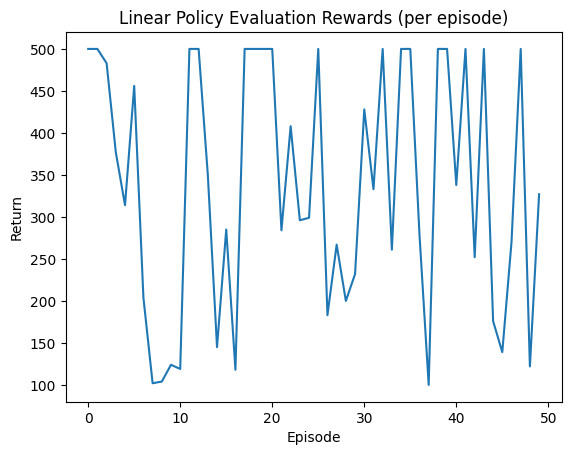

In [ ]:
mean_r, std_r, rewards = evaluate_policy(pi_linear)

print("Linear policy mean return:", mean_r, "stdev=",std_r)

plt.plot(rewards)
plt.title("Linear Policy Evaluation Rewards (per episode)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()


In [ ]:
torch.save(pi_linear.state_dict(), "pi3_cartpole.pth")


In [ ]:
from collections import deque
from tqdm import tqdm
from torch.distributions import Categorical

def train_pi2_until_threshold(
    env_name="CartPole-v1",
    lr=3e-4,
    max_steps=3000,
    target_reward=100,
    window_size=20,
    save_path="pi2_cartpole.pth"
):
    env = gym.make(env_name)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = Policy(obs_dim, act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    gamma = 0.99
    reward_window = deque(maxlen=window_size)

    pbar = tqdm(range(max_steps), desc="Training π2")

    for step in pbar:
        traj, ep_reward = rollout(env, policy)
        reward_window.append(ep_reward)

        # PPO update (same as before)
        returns = []
        G = 0
        for _, _, r in reversed(traj):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for (obs, action, _), R in zip(traj, returns):
            obs_t = torch.tensor(obs, dtype=torch.float32)

            logits, value = policy(obs_t)
            dist = Categorical(logits=logits)

            log_prob = dist.log_prob(torch.tensor(action))
            advantage = R - value.item()

            loss += -log_prob * advantage + (R - value.squeeze())**2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_reward = np.mean(reward_window)

        pbar.set_postfix({
            "episode_reward": ep_reward,
            "avg_reward": avg_reward
        })

        if len(reward_window) == window_size and avg_reward >= target_reward:
            print(f"\nReached target avg reward {avg_reward:.2f}, saving π2...")

            torch.save(policy.state_dict(), save_path)

            env.close()
            return policy

    print("Max steps reached, saving final policy anyway.")
    torch.save(policy.state_dict(), save_path)
    env.close()
    return policy


In [ ]:
pi2 = train_pi2_until_threshold()
#Pi2 trained till window avg reaches specified threshold

Training π2:  14%|█▍        | 430/3000 [00:27<02:46, 15.43it/s, episode_reward=24, avg_reward=100]


Reached target avg reward 100.15, saving π2...


In [ ]:
pi2 = Policy(4, 2)
pi2.load_state_dict(torch.load("/content/drive/MyDrive/RL_project/pi2_cartpole.pth"))

<All keys matched successfully>

Evaluating Policy: 100%|██████████| 50/50 [00:02<00:00, 19.47it/s, avg_reward=226]


π2 Mean Return: 226.46
π2 Std Return: 79.06


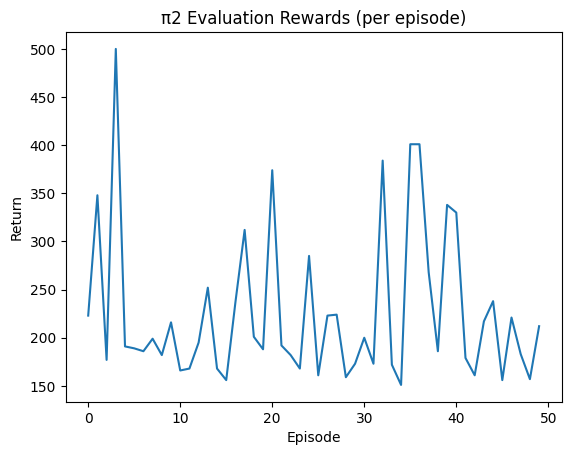

In [ ]:
mean_r, std_r, rewards = evaluate_policy(pi2)

print(f"π2 Mean Return: {mean_r:.2f}")
print(f"π2 Std Return: {std_r:.2f}")
plt.plot(rewards)
plt.title("π2 Evaluation Rewards (per episode)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

In [ ]:
torch.save(pi2.state_dict(), "pi2_cartpole.pth")

In [ ]:
def generate_preference_dataset(env, pi1, pi2, K=200):
    dataset = []

    for _ in tqdm(range(K), desc="Generating preferences"):
        tau1, r1 = rollout(env, pi1)
        tau2, r2 = rollout(env, pi2)

        # preference probability
        p = np.exp(r1) / (np.exp(r1) + np.exp(r2))

        if np.random.rand() < p:
            pref, rej = tau1, tau2
        else:
            pref, rej = tau2, tau1

        dataset.append((pref, rej))

    return dataset

In [ ]:
import gymnasium as gym
import pickle
import os

os.makedirs("/content/drive/MyDrive/RL_project/datasets", exist_ok=True)

env = gym.make("CartPole-v1")

dataset_sizes = [20, 50, 100, 200, 400]

for K in dataset_sizes:
    prefs = generate_preference_dataset(env, pi1, pi2, K=K)

    save_path = f"/content/drive/MyDrive/RL_project/datasets/cartpole_preferences_{K}.pkl"

    with open(save_path, "wb") as f:
        pickle.dump(prefs, f)

    print(f"Saved dataset with {K} preferences to {save_path}")

Generating preferences: 100%|██████████| 20/20 [00:03<00:00,  5.64it/s]


Saved dataset with 20 preferences to /content/drive/MyDrive/RL_project/datasets/cartpole_preferences_20.pkl


Generating preferences: 100%|██████████| 50/50 [00:07<00:00,  7.04it/s]


Saved dataset with 50 preferences to /content/drive/MyDrive/RL_project/datasets/cartpole_preferences_50.pkl


Generating preferences: 100%|██████████| 100/100 [00:16<00:00,  6.21it/s]


Saved dataset with 100 preferences to /content/drive/MyDrive/RL_project/datasets/cartpole_preferences_100.pkl


Generating preferences: 100%|██████████| 200/200 [00:31<00:00,  6.33it/s]


Saved dataset with 200 preferences to /content/drive/MyDrive/RL_project/datasets/cartpole_preferences_200.pkl


Generating preferences: 100%|██████████| 400/400 [01:01<00:00,  6.51it/s]


Saved dataset with 400 preferences to /content/drive/MyDrive/RL_project/datasets/cartpole_preferences_400.pkl


In [ ]:
env = gym.make("CartPole-v1")
prefs = generate_preference_dataset(env, pi1, pi2, K=200)

Generating preferences: 100%|██████████| 200/200 [00:29<00:00,  6.68it/s]


In [ ]:
from tqdm import tqdm
import torch
import torch.nn.functional as F
import copy
import pickle

dataset_sizes = [20, 50, 100, 200, 400]
seeds = [42, 123, 7]
#betas = [0.01, 0.05, 0.1, 0.5]
betas = [0.25, 1, 2, 5]

num_eval_rollouts = 50
epochs = 80
lr = 1e-3

# all_results[K][beta][seed] = {"pi1", "pi3", "dpo"}
all_results2 = {K: {b: {} for b in betas} for K in dataset_sizes}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move base policies once
pi1 = pi1.to(device).eval()
pi3 = pi3.to(device).eval()

for beta in betas:
    print(f"\n{'='*40}\nDPO beta = {beta}\n{'='*40}")

    for SEED in seeds:
        print(f"  Seed = {SEED}")
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        for K in tqdm(dataset_sizes, desc=f"beta={beta} seed={SEED}"):

            # load preference dataset
            with open(f"/content/drive/MyDrive/RL_project/datasets/cartpole_preferences_{K}.pkl", "rb") as f:
                prefs = pickle.load(f)

            # clone policy from reference
            policy = copy.deepcopy(pi3).to(device)
            policy.train()

            # freeze reference model properly
            ref_policy = copy.deepcopy(pi3).to(device)
            ref_policy.eval()
            for p in ref_policy.parameters():
                p.requires_grad = False

            optimizer = torch.optim.AdamW(policy.parameters(), lr=lr)

            # DPO TRAINING LOOP
            for ep in tqdm(range(epochs), leave=False):

                total_loss = 0.0
                indices = torch.randperm(len(prefs)).tolist()

                for idx in indices:

                    pref_traj, rej_traj = prefs[idx]

                    # BUILD TENSORS ONCE
                    pref_obs = torch.tensor([t[0] for t in pref_traj],
                                            dtype=torch.float32,
                                            device=device)
                    pref_act = torch.tensor([t[1] for t in pref_traj],
                                            dtype=torch.long,
                                            device=device)
                    rej_obs = torch.tensor([t[0] for t in rej_traj],
                                           dtype=torch.float32,
                                           device=device)
                    rej_act = torch.tensor([t[1] for t in rej_traj],
                                           dtype=torch.long,
                                           device=device)

                    # POLICY LOG PROBS
                    logits, _ = policy(pref_obs)  # actor head only
                    log_probs = F.log_softmax(logits, dim=-1)
                    pi_pref = log_probs.gather(1, pref_act.unsqueeze(1)).squeeze(1).sum()

                    logits, _ = policy(rej_obs)
                    log_probs = F.log_softmax(logits, dim=-1)
                    pi_rej = log_probs.gather(1, rej_act.unsqueeze(1)).squeeze(1).sum()

                    # REFERENCE LOG PROBS (NO GRAD)
                    with torch.no_grad():
                        ref_logits, _ = ref_policy(pref_obs)
                        ref_log_probs = F.log_softmax(ref_logits, dim=-1)
                        ref_pref = ref_log_probs.gather(1, pref_act.unsqueeze(1)).squeeze(1).sum()

                        ref_logits, _ = ref_policy(rej_obs)
                        ref_log_probs = F.log_softmax(ref_logits, dim=-1)
                        ref_rej = ref_log_probs.gather(1, rej_act.unsqueeze(1)).squeeze(1).sum()

                    # DPO OBJECTIVE
                    pi_diff = pi_pref - pi_rej
                    ref_diff = ref_pref - ref_rej

                    dpo_logit = beta * (pi_diff - ref_diff)

                    loss = F.softplus(-dpo_logit)  # stable -log(sigmoid)

                    # OPTIM STEP
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)

                    optimizer.step()

                    total_loss += loss.item()

                print(f"beta={beta} Seed={SEED} K={K} | Epoch {ep+1} | Loss: {total_loss/len(prefs):.4f}")

            policy.eval()

            # EVALUATION
            pi1_mean, pi1_std, pi1_rewards = evaluate_policy(pi1, "CartPole-v1", episodes=num_eval_rollouts)
            pi3_mean, pi3_std, pi3_rewards = evaluate_policy(pi3, "CartPole-v1", episodes=num_eval_rollouts)
            dpo_mean, dpo_std, dpo_rewards = evaluate_policy(policy, "CartPole-v1", episodes=num_eval_rollouts)

            all_results2[K][beta][SEED] = {
                "pi1": pi1_rewards,
                "pi3": pi3_rewards,
                "dpo": dpo_rewards
            }



DPO beta = 0.25
  Seed = 42


  0%|          | 0/80 [00:00<?, ?it/s]/tmp/ipykernel_848/3327075682.py:64: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  pref_obs = torch.tensor([t[0] for t in pref_traj],

  4%|▍         | 3/80 [00:00<00:19,  3.90it/s]

beta=0.25 Seed=42 K=20 | Epoch 1 | Loss: 0.6723
beta=0.25 Seed=42 K=20 | Epoch 2 | Loss: 0.6217
beta=0.25 Seed=42 K=20 | Epoch 3 | Loss: 0.5849
beta=0.25 Seed=42 K=20 | Epoch 4 | Loss: 0.5471



  9%|▉         | 7/80 [00:01<00:08,  8.17it/s]

beta=0.25 Seed=42 K=20 | Epoch 5 | Loss: 0.5183
beta=0.25 Seed=42 K=20 | Epoch 6 | Loss: 0.4877
beta=0.25 Seed=42 K=20 | Epoch 7 | Loss: 0.4646


...


 99%|█████████▉| 79/80 [01:45<00:01,  1.28s/it]

beta=5 Seed=7 K=400 | Epoch 79 | Loss: 0.2565



100%|██████████| 80/80 [01:47<00:00,  1.28s/it]
                                               

beta=5 Seed=7 K=400 | Epoch 80 | Loss: 0.2557


beta=5 seed=7: 100%|██████████| 5/5 [05:39<00:00, 67.87s/it]


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ── PRH / ICML style ──────────────────────────────────────────────
PRH_STYLE = {
    # Figure & axes
    "figure.facecolor": "white",
    "figure.dpi": 150,
    "axes.facecolor": "#F8F9FA",
    "axes.edgecolor": "#C8CDD4",
    "axes.linewidth": 1.2,
    "axes.grid": True,
    "axes.axisbelow": True,
    # Grid
    "grid.color": "#ECEDEC",
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    # Labels & ticks
    "axes.labelcolor": "#324766",
    "axes.titlecolor": "#324766",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelpad": 3,
    "axes.titlepad": 8,
    "xtick.color": "#3B4F6D",
    "ytick.color": "#3B4F6D",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    # Lines & markers
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "lines.markeredgewidth": 0.5,
    # Legend
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.facecolor": "white",
    "legend.edgecolor": "#C8CDD4",
    "legend.fontsize": 8,
    "legend.shadow": True,
    "legend.columnspacing": 1.0,
    "legend.labelspacing": 0.3,
    # Export
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
mpl.rcParams.update(PRH_STYLE)

# Palette — distinct, colourblind-friendly
PRH_COLORS = {
    "optimal":   "#2D6A4F",   # deep green  → π1
    "reference": "#6C757D",   # slate grey   → π3 / ref
    "dpo":       "#3A5FA8",   # steel blue   → DPO
    "rlhf":      ["#3A5FA8", "#E07B2A", "#9B4E9B", "#D94F3D", "#2BA6A1"],  # K colours
}
print("PRH style loaded.")


PRH style loaded.


In [ ]:
import os, zipfile
from google.colab import files

save_dir = "dpo_plots"
os.makedirs(save_dir, exist_ok=True)

for K in sorted(all_results2.keys()):
    for beta in betas:

        pi1_all = np.array([all_results2[K][beta][s]["pi1"] for s in seeds])
        pi3_all = np.array([all_results2[K][beta][s]["pi3"] for s in seeds])
        dpo_all = np.array([all_results2[K][beta][s]["dpo"] for s in seeds])

        episodes = np.arange(pi1_all.shape[1])

        fig, ax = plt.subplots(figsize=(5.5, 3.5))

        m, s = pi1_all.mean(0), pi1_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["optimal"], label="π1 (optimal)")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["optimal"], alpha=0.15, linewidth=0)

        m, s = pi3_all.mean(0), pi3_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["reference"], label="π3 (reference)", linestyle="--")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["reference"], alpha=0.15, linewidth=0)

        m, s = dpo_all.mean(0), dpo_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["dpo"], label=f"DPO (K={K}, β={beta})")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["dpo"], alpha=0.15, linewidth=0)

        ax.set_xlabel("Episode")
        ax.set_ylabel("Return")
        ax.set_title(f"DPO  —  K={K},  β={beta}  ({len(seeds)} seeds, mean ± std)")
        ax.legend(loc="lower right")

        plt.tight_layout()
        fname = os.path.join(save_dir, f"dpo_K{K}_beta{beta}.png")
        plt.savefig(fname, dpi=300)
        plt.close()

# Zip and download
zip_path = "dpo_plots.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in os.listdir(save_dir):
        zf.write(os.path.join(save_dir, fname), arcname=fname)

files.download(zip_path)
print(f"Downloaded {zip_path} with {len(os.listdir(save_dir))} plots.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded dpo_plots.zip with 20 plots.


In [ ]:
import pickle, shutil, os

drive_save_dir = "/content/drive/MyDrive/RL_project/results"
save_dir = "/content/drive/MyDrive/RL_project/results"
os.makedirs(drive_save_dir, exist_ok=True)

# Save results dict
results_path = os.path.join(drive_save_dir, "dpo_all_results2.pkl")
with open(results_path, "wb") as f:
    pickle.dump(all_results2, f)

# Also copy the plots folder to Drive
drive_plots_dir = os.path.join(drive_save_dir, "dpo_plots")
if os.path.exists(drive_plots_dir):
    shutil.rmtree(drive_plots_dir)
shutil.copytree(save_dir, drive_plots_dir)

print(f"Saved results to {results_path}")
print(f"Saved plots to {drive_plots_dir}")

Saved results to /content/drive/MyDrive/RL_project/results/dpo_all_results2.pkl
Saved plots to /content/drive/MyDrive/RL_project/results/dpo_plots


### PPO-RLHF

In [ ]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, states):
        return self.net(states).squeeze(-1)

In [ ]:
import pickle
import torch.nn.functional as F
from tqdm import tqdm


def trajectory_reward(reward_model, traj, device):
    states = torch.tensor([x[0] for x in traj], dtype=torch.float32).to(device)
    rewards = reward_model(states)
    return rewards.sum()


def train_reward_model(dataset_path, obs_dim=4, epochs=10, lr=1e-3):

    with open(dataset_path, "rb") as f:
        prefs = pickle.load(f)

    reward_model = RewardModel(obs_dim).to(device)

    optimizer = optim.Adam(reward_model.parameters(), lr=lr)

    for epoch in range(epochs):

        total_loss = 0

        for pref, rej in tqdm(prefs, desc=f"Reward Epoch {epoch}"):

            r_pref = trajectory_reward(reward_model, pref, device)
            r_rej = trajectory_reward(reward_model, rej, device)

            loss = -F.logsigmoid(r_pref - r_rej)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch} Loss: {total_loss / len(prefs):.4f}")

    return reward_model

In [ ]:
from torch.distributions import Categorical

def rollout_rlhf(env, policy, reward_model, max_steps=200):

    obs, _ = env.reset()

    traj = []

    for _ in range(max_steps):

        obs_t = torch.tensor(obs, dtype=torch.float32).to(device)

        logits, value = policy(obs_t)

        dist = Categorical(logits=logits)

        action = dist.sample()

        next_obs, _, terminated, truncated, _ = env.step(action.item())

        with torch.no_grad():
            learned_reward = reward_model(obs_t.unsqueeze(0)).item()

        traj.append((
            obs,
            action.item(),
            learned_reward,
            dist.log_prob(action).item(),
            value.item()
        ))

        obs = next_obs

        if terminated or truncated:
            break

    return traj

In [ ]:
import copy
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
from tqdm import tqdm

def train_ppo_rlhf(
    reward_model,
    base_policy,
    env_name="CartPole-v1",
    steps=1500,
    lr=3e-4,
    gamma=0.99,
    clip_eps=0.2,
    ppo_epochs=4,
    beta=0.1
):
    env = gym.make(env_name)

    policy = copy.deepcopy(base_policy).to(device)
    ref_policy = copy.deepcopy(base_policy).to(device)
    ref_policy.eval()
    for p in ref_policy.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    reward_history = []

    for step in tqdm(range(steps), desc="PPO-RLHF"):

        traj = rollout_rlhf(env, policy, reward_model)

        obs = torch.tensor([x[0] for x in traj], dtype=torch.float32).to(device)
        actions = torch.tensor([x[1] for x in traj]).to(device)
        rewards = [x[2] for x in traj]
        old_log_probs = torch.tensor([x[3] for x in traj]).to(device)
        values = torch.tensor([x[4] for x in traj]).to(device)

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        advantages = returns - values.detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(ppo_epochs):

            # Single forward pass — used for PPO ratio, KL, and critic
            logits, new_values = policy(obs)
            dist = Categorical(logits=logits)
            new_log_probs = dist.log_prob(actions)

            # PPO ratio
            ratio = torch.exp(new_log_probs - old_log_probs)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages

            # KL to reference policy (RLHF term)
            with torch.no_grad():
                ref_logits, _ = ref_policy(obs)

            log_probs = torch.log_softmax(logits, dim=-1)
            ref_log_probs = torch.log_softmax(ref_logits, dim=-1)

            pi = torch.softmax(logits, dim=-1)

            kl = (pi * (log_probs - ref_log_probs)).sum(dim=-1)
            kl_loss = beta * kl.mean()

            # PPO actor loss + KL penalty
            actor_loss = -torch.min(surr1, surr2).mean()

            critic_loss = F.mse_loss(new_values.squeeze(), returns)

            loss = actor_loss + kl_loss + 0.5 * critic_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        reward_history.append(sum(rewards))

        if step % 100 == 0:
            print(f"Step {step} Learned Return: {np.mean(reward_history[-20:]):.2f}")

    return policy, reward_history

In [ ]:
dataset_sizes = [20, 50, 100, 200, 400]
seeds = [42, 123, 7]
#betas = [0.01, 0.5, 2.0, 8.0]
betas = [0.2, 1, 4]
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# rlhf_results[K][beta][seed] = {"mean", "std", "eval_rewards", "train_rewards"}
rlhf_results2 = {K: {b: {} for b in betas} for K in dataset_sizes}

for beta in betas:
    print(f"\n{'='*40}\nRLHF beta = {beta}\n{'='*40}")

    for SEED in seeds:
        print(f"  Seed = {SEED}")
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        for K in dataset_sizes:

            print(f"\n  Training reward model  K={K}")
            dataset_path = f"/content/drive/MyDrive/RL_project/datasets/cartpole_preferences_{K}.pkl"

            # IMPORTANT: retrain reward model per dataset
            reward_model = train_reward_model(dataset_path)

            # IMPORTANT: fresh copy of base policy each run
            base_policy_copy = copy.deepcopy(pi4).to(device)

            print(f"  Training PPO-RLHF  K={K}  beta={beta}  seed={SEED}")

            rlhf_policy, train_rewards = train_ppo_rlhf(
                reward_model=reward_model,
                base_policy=base_policy_copy,
                steps=1500,
                beta=beta,
                gamma=0.99,
                clip_eps=0.2,
                ppo_epochs=4
            )

            mean_reward, std_reward, eval_rewards = evaluate_policy(rlhf_policy)

            rlhf_results2[K][beta][SEED] = {
                "mean": mean_reward,
                "std": std_reward,
                "eval_rewards": eval_rewards,
                "train_rewards": train_rewards,

            }

            print(f"  K={K}  beta={beta}  seed={SEED}  →  mean return: {mean_reward:.2f}")



RLHF beta = 0.2
  Seed = 42

  Training reward model  K=20


Reward Epoch 0:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1764/512242613.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor([x[0] for x in traj], dtype=torch.float32).to(device)
Reward Epoch 0: 100%|██████████| 20/20 [00:00<00:00, 31.83it/s]


Epoch 0 Loss: 0.5603


Reward Epoch 1: 100%|██████████| 20/20 [00:00<00:00, 342.59it/s]


Epoch 1 Loss: 0.0025


...

Step 1300 Learned Return: 6.65


PPO-RLHF:  93%|█████████▎| 1401/1500 [01:56<00:07, 12.48it/s]

Step 1400 Learned Return: 8.17


PPO-RLHF: 100%|██████████| 1500/1500 [02:04<00:00, 12.04it/s]


  K=400  beta=4  seed=7  →  mean return: 310.52


In [ ]:
# Evaluate pi1 and pi4 baselines across seeds and inject into rlhf_results
num_eval_rollouts = 50

for SEED in seeds:
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    print('SEED:',SEED)
    for beta in betas:
        print('Beta:',beta)
        for K in dataset_sizes:
            _, _, pi1_rewards = evaluate_policy(pi1, "CartPole-v1", episodes=num_eval_rollouts)
            _, _, pi4_rewards = evaluate_policy(pi4, "CartPole-v1", episodes=num_eval_rollouts)

            rlhf_results2[K][beta][SEED]["pi1"] = pi1_rewards
            rlhf_results2[K][beta][SEED]["pi4"] = pi4_rewards

print("Done — pi1 and pi4 evals injected into rlhf_results.")

SEED: 42
Beta: 0.01
Beta: 0.5
Beta: 2.0
Beta: 8.0
SEED: 123
Beta: 0.01
Beta: 0.5
Beta: 2.0
Beta: 8.0
SEED: 7
Beta: 0.01
Beta: 0.5
Beta: 2.0
Beta: 8.0
Done — pi1 and pi4 evals injected into rlhf_results.


In [ ]:
import os, zipfile
from google.colab import files

save_dir = "rlhf_plots"
os.makedirs(save_dir, exist_ok=True)

for K in sorted(rlhf_results2.keys()):
    for beta in betas:

        pi1_all  = np.array([rlhf_results2[K][beta][s]["pi1"]  for s in seeds])
        pi4_all  = np.array([rlhf_results2[K][beta][s]["pi4"]  for s in seeds])
        rlhf_all = np.array([rlhf_results2[K][beta][s]["eval_rewards"] for s in seeds])

        episodes = np.arange(pi1_all.shape[1])

        fig, ax = plt.subplots(figsize=(5.5, 3.5))

        # π1 — optimal
        m, s = pi1_all.mean(0), pi1_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["optimal"], label="π1 (optimal)")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["optimal"], alpha=0.15, linewidth=0)

        # π4 — base policy (reference for RLHF)
        m, s = pi4_all.mean(0), pi4_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["reference"], label="π4 (base)", linestyle="--")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["reference"], alpha=0.15, linewidth=0)

        # PPO-RLHF
        m, s = rlhf_all.mean(0), rlhf_all.std(0)
        ax.plot(episodes, m, color=PRH_COLORS["dpo"], label=f"PPO-RLHF (K={K}, β={beta})")
        ax.fill_between(episodes, m - s, m + s,
                        color=PRH_COLORS["dpo"], alpha=0.15, linewidth=0)

        ax.set_xlabel("Episode")
        ax.set_ylabel("Return")
        ax.set_title(f"PPO-RLHF  —  K={K},  β={beta}  ({len(seeds)} seeds, mean ± std)")
        ax.legend(loc="lower right")

        plt.tight_layout()
        fname = os.path.join(save_dir, f"ppo_rlhf_K{K}_beta{beta}.png")
        plt.savefig(fname, dpi=300)
        plt.close()

# Zip and download
zip_path = "rlhf_plots.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in os.listdir(save_dir):
        zf.write(os.path.join(save_dir, fname), arcname=fname)

files.download(zip_path)
print(f"Downloaded {zip_path} with {len(os.listdir(save_dir))} plots.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded rlhf_plots.zip with 20 plots.


In [ ]:
import pickle, shutil
import os

drive_save_dir = "/content/drive/MyDrive/RL_project/results"
save_dir = "/content/drive/MyDrive/RL_project/results"
os.makedirs(drive_save_dir, exist_ok=True)

# Save results dict
results_path = os.path.join(drive_save_dir, "rlhf_all_results2.pkl")
with open(results_path, "wb") as f:
    pickle.dump(rlhf_results2, f)

# Also copy the plots folder to Drive
drive_plots_dir = os.path.join(drive_save_dir, "rlhf_plots2")
if os.path.exists(drive_plots_dir):
    shutil.rmtree(drive_plots_dir)
shutil.copytree(save_dir, drive_plots_dir)

print(f"Saved results to {results_path}")
print(f"Saved plots to {drive_plots_dir}")

Saved results to /content/drive/MyDrive/RL_project/results/rlhf_all_results2.pkl
Saved plots to /content/drive/MyDrive/RL_project/results/rlhf_plots2


### Plots for Report/Poster

Using — DPO β=0.25,  PPO-RLHF β=0.01,  K=400
Saved: cartpole_2x2_final.png  |  cartpole_2x2_final.pdf


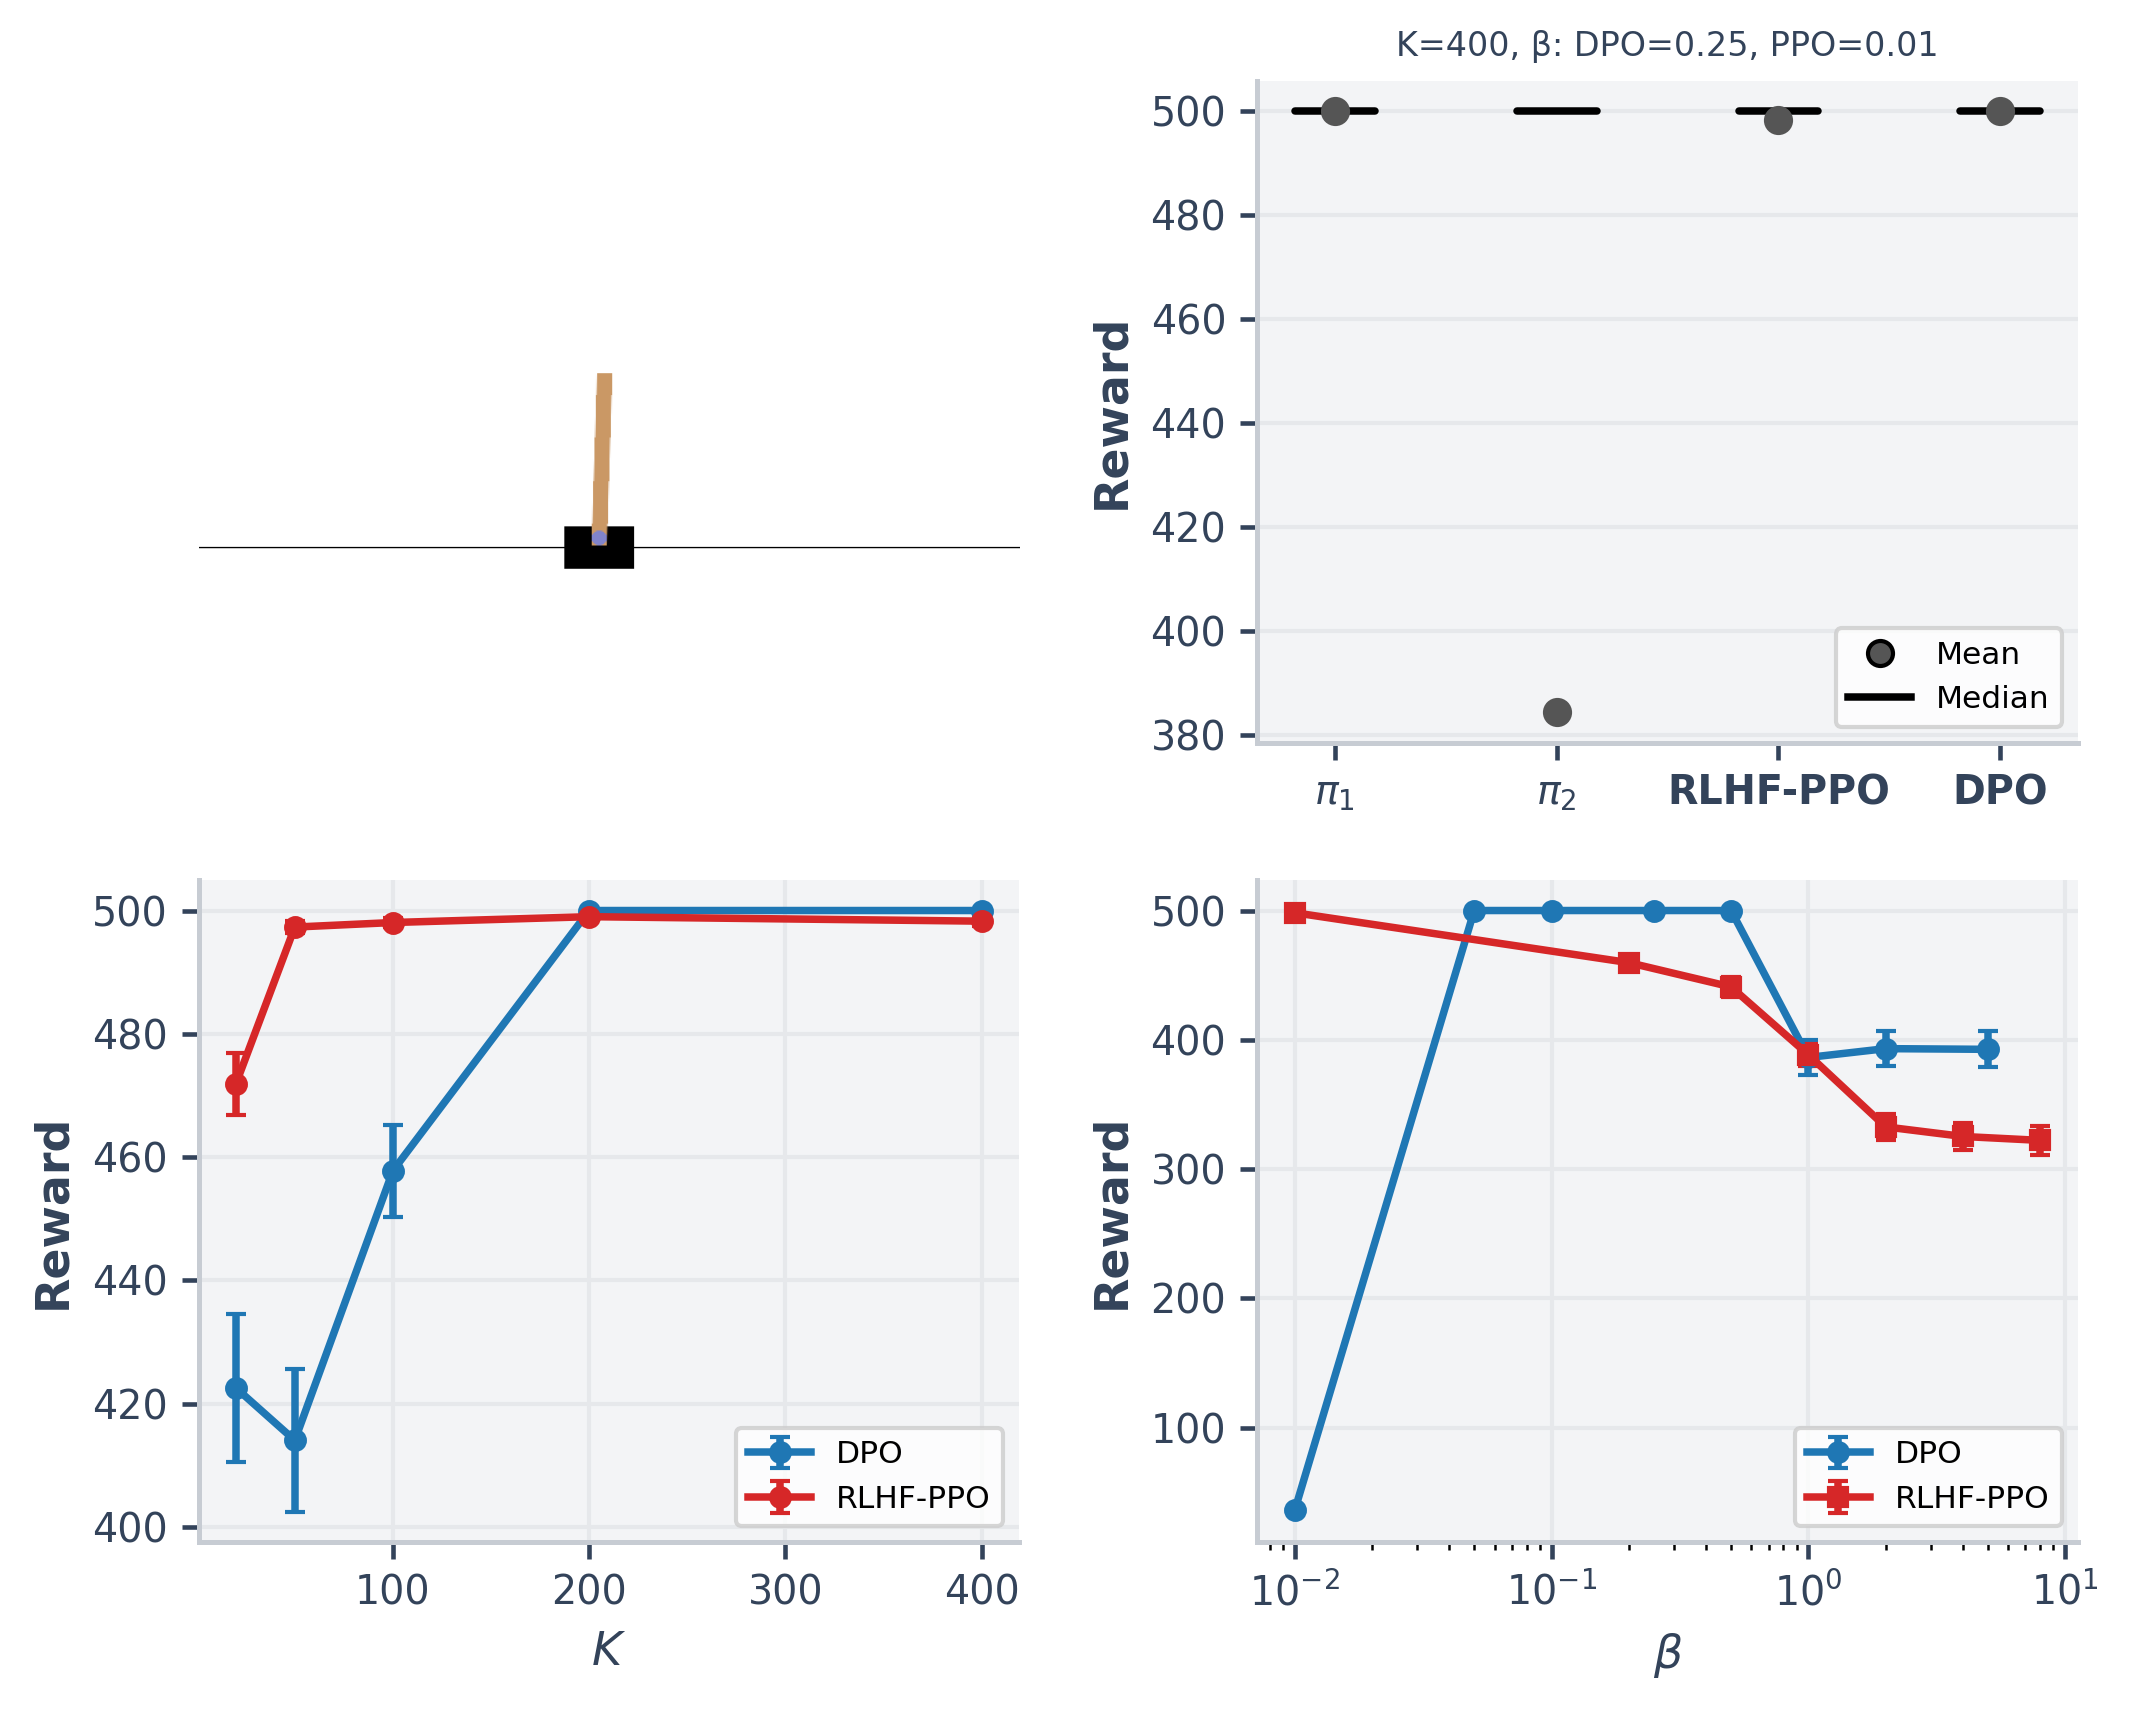

In [ ]:
# ============================================================
# 2x2 REPORT FIGURE — CartPole
# A: CartPole environment snapshot
# B: Final policy comparison (π1, π2, DPO, PPO-RLHF) — dot=mean, line=median
# C: K sweep  (DPO, PPO-RLHF)
# D: β sweep  (DPO, PPO-RLHF)
# ============================================================

# Notes:
# Results were saved in 2 batches since the compute exceeded colab limits in some cases. These results are merged here for the plots. For the average
# comparison against pi1 and pu2, the best-performing beta for both algorithms was chosen. Plots C and D cover effect of K (for fixed beta) and effect
# of beta (for fixed K)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle

# USER CONFIG
DPO_PKL1  = "/content/drive/MyDrive/RL_project/results/dpo_all_results.pkl"
DPO_PKL2  = "/content/drive/MyDrive/RL_project/results/dpo_all_results2.pkl"
RLHF_PKL1 = "/content/drive/MyDrive/RL_project/results/rlhf_all_results.pkl"
RLHF_PKL2 = "/content/drive/MyDrive/RL_project/results/rlhf_all_results2.pkl"

SEEDS  = [42, 123, 7]
BEST_K = 400

BEST_BETA_DPO = 0.25
BEST_BETA_PPO = 0.01

OUT_PNG = "cartpole_2x2_final.png"
OUT_PDF = "cartpole_2x2_final.pdf"

# HELPERS
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def merge_results(r1, r2, K):
    out = {}
    out.update(r1[K])
    out.update(r2[K])
    return out

def seeds_mean(data_at_beta, key):
    vals = []
    for s in SEEDS:
        vals.extend(data_at_beta[s][key])
    return np.array(vals, dtype=float)

def k_sweep_series_fixed_beta(dpo1, dpo2, ppo1, ppo2, Ks, dpo_best_b, ppo_best_b):
    series = {k: {"means": [], "sems": []} for k in ["dpo", "ppo"]}
    for K in Ks:
        md = merge_results(dpo1, dpo2, K)
        mp = merge_results(ppo1, ppo2, K)
        for vals, canon in [
            (seeds_mean(md[dpo_best_b], "dpo"),          "dpo"),
            (seeds_mean(mp[ppo_best_b], "eval_rewards"), "ppo"),
        ]:
            series[canon]["means"].append(vals.mean())
            series[canon]["sems"].append(vals.std() / np.sqrt(len(vals)))
    for canon in series:
        series[canon]["means"] = np.array(series[canon]["means"])
        series[canon]["sems"]  = np.array(series[canon]["sems"])
    return series

def beta_sweep(data, key):
    betas = sorted(data.keys())
    means, sems = [], []
    for b in betas:
        vals = []
        for s in SEEDS:
            vals.extend(data[b][s][key])
        vals = np.array(vals, dtype=float)
        means.append(vals.mean())
        sems.append(vals.std() / np.sqrt(len(vals)))
    return np.array(betas), np.array(means), np.array(sems)

# STYLE
TEXT_COLOR = "#33435a"
GRID_COLOR = "#e6e8eb"
BG_COLOR   = "#f3f4f6"
COLORS     = {"p1": "#2ca02c", "p2": "#ff7f0e", "ppo": "#d62728", "dpo": "#1f77b4"}
LABELS     = {"p1": r"$\pi_1$", "p2": r"$\pi_2$", "ppo": "RLHF-PPO", "dpo": "DPO"}

def style_axis(ax):
    ax.set_facecolor(BG_COLOR)
    ax.grid(True, color=GRID_COLOR, linewidth=1.0)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color("#c7ccd3")
        ax.spines[sp].set_linewidth(1.2)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9.5, width=1.1, length=4)

# LOAD DATA
dpo1, dpo2 = load_pkl(DPO_PKL1), load_pkl(DPO_PKL2)
ppo1, ppo2 = load_pkl(RLHF_PKL1), load_pkl(RLHF_PKL2)

Ks = sorted(set(dpo1.keys()) & set(dpo2.keys()))

dpo_at_best_K = merge_results(dpo1, dpo2, BEST_K)
ppo_at_best_K = merge_results(ppo1, ppo2, BEST_K)

assert BEST_BETA_DPO in dpo_at_best_K, \
    f"BEST_BETA_DPO={BEST_BETA_DPO} not found. Available: {sorted(dpo_at_best_K.keys())}"
assert BEST_BETA_PPO in ppo_at_best_K, \
    f"BEST_BETA_PPO={BEST_BETA_PPO} not found. Available: {sorted(ppo_at_best_K.keys())}"

print(f"Using — DPO β={BEST_BETA_DPO},  PPO-RLHF β={BEST_BETA_PPO},  K={BEST_K}")

# PRE-COMPUTE SERIES
any_b    = next(iter(dpo_at_best_K))
pi1_vals = seeds_mean(dpo_at_best_K[any_b],         "pi1")
pi2_vals = seeds_mean(dpo_at_best_K[any_b],         "pi3")
dpo_vals = seeds_mean(dpo_at_best_K[BEST_BETA_DPO], "dpo")
ppo_vals = seeds_mean(ppo_at_best_K[BEST_BETA_PPO], "eval_rewards")

ksweep = k_sweep_series_fixed_beta(dpo1, dpo2, ppo1, ppo2, Ks, BEST_BETA_DPO, BEST_BETA_PPO)

dpo_betas, dpo_means, dpo_sems = beta_sweep(dpo_at_best_K, "dpo")
ppo_betas, ppo_means, ppo_sems = beta_sweep(ppo_at_best_K, "eval_rewards")

# DRAW
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), dpi=300)
ax_a, ax_b, ax_c, ax_d = axes.ravel()

# A: Illustration
import gymnasium as gym

_cp_env = gym.make("CartPole-v1", render_mode="rgb_array")
_cp_env.reset(seed=0)
for _ in range(12):
    _obs, _, _done, _trunc, _ = _cp_env.step(_cp_env.action_space.sample())
    if _done or _trunc:
        _cp_env.reset(seed=0)
_cp_frame = _cp_env.render()
_cp_env.close()

ax_a.imshow(_cp_frame)
ax_a.set_xticks([])
ax_a.set_yticks([])
ax_a.set_frame_on(False)

# B: Final comparison
algo_order = ["p1", "p2", "ppo", "dpo"]
all_vals   = [pi1_vals, pi2_vals, ppo_vals, dpo_vals]
xlabels    = [LABELS[a] for a in algo_order]
positions  = np.arange(len(algo_order))

DOT_COLOR = "#555555"

ax_b.set_facecolor(BG_COLOR)
ax_b.set_axisbelow(True)
ax_b.grid(True, axis="y", color=GRID_COLOR, linewidth=1.0)

for pos, (canon, vals) in enumerate(zip(algo_order, all_vals)):
    mean = vals.mean()
    med  = np.median(vals)
    ax_b.plot([pos - 0.18, pos + 0.18], [med, med],
              color="black", linewidth=1.8, solid_capstyle="round", zorder=3)
    ax_b.scatter([pos], [mean], color=DOT_COLOR, s=36, zorder=4)

ax_b.set_xticks(positions)
ax_b.set_xticklabels(xlabels, fontsize=9.5, fontweight="bold", color=TEXT_COLOR)
ax_b.set_ylabel("Reward", fontsize=11, fontweight="bold", color=TEXT_COLOR)
ax_b.set_title(f"K={BEST_K}, β: DPO={BEST_BETA_DPO}, PPO={BEST_BETA_PPO}",
               fontsize=8, color=TEXT_COLOR)
ax_b.legend(handles=[
    Line2D([0],[0], marker="o", color="none", markerfacecolor=DOT_COLOR,
           markersize=6, label="Mean"),
    Line2D([0],[0], color="black", linewidth=1.8, label="Median"),
], loc="lower right", frameon=True, fontsize=7.5)
for sp in ["top", "right"]:
    ax_b.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax_b.spines[sp].set_color("#c7ccd3")
    ax_b.spines[sp].set_linewidth(1.2)
ax_b.tick_params(colors=TEXT_COLOR, labelsize=9.5, width=1.1, length=4)

# C: K sweep — DPO and PPO-RLHF only
for canon in ["dpo", "ppo"]:
    ax_c.errorbar(
        Ks,
        ksweep[canon]["means"],
        yerr=ksweep[canon]["sems"],
        marker="o", markersize=4.5, linewidth=1.8, capsize=2.5,
        color=COLORS[canon], label=LABELS[canon],
    )
ax_c.set_xlabel("$K$", fontsize=11, fontweight="bold", color=TEXT_COLOR)
ax_c.set_ylabel("Reward", fontsize=11, fontweight="bold", color=TEXT_COLOR)
ax_c.legend(frameon=True, fontsize=7.5, loc="lower right")
style_axis(ax_c)

# D: BETA sweep
ax_d.errorbar(dpo_betas, dpo_means, yerr=dpo_sems,
    marker="o", markersize=4.5, linewidth=1.8, capsize=2.5,
    color=COLORS["dpo"], label="DPO")
ax_d.errorbar(ppo_betas, ppo_means, yerr=ppo_sems,
    marker="s", markersize=4.5, linewidth=1.8, capsize=2.5,
    color=COLORS["ppo"], label="RLHF-PPO")
ax_d.set_xscale("log")
ax_d.set_xlabel(r"$\beta$", fontsize=11, fontweight="bold", color=TEXT_COLOR)
ax_d.set_ylabel("Reward", fontsize=11, fontweight="bold", color=TEXT_COLOR)
ax_d.legend(frameon=True, fontsize=7.5, loc="lower right")
style_axis(ax_d)

#SAVE
plt.tight_layout(w_pad=1.6, h_pad=1.6)
fig.savefig(OUT_PDF, bbox_inches="tight")
fig.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
print(f"Saved: {OUT_PNG}  |  {OUT_PDF}")
plt.show()